# Embeddings Médicos con COWESE
### Word2Vec vs FastText 

**Pipeline:**
1. Importar librerias y cargar el corpus
2. Preprocesamiento y tokenización
3. Entrenamiento Word2Vec y FastText
4. Evaluación: Analogías · Similitud · Clasificación · Antónimos
5. Exportación del modelo en formato TXT

## 1. Importar librerias y cargar el corpus

In [18]:
import os, re, time, gc
import nltk
import numpy as np
from gensim.models import Word2Vec, FastText
from gensim.models.callbacks import CallbackAny2Vec  
from nltk.tokenize import sent_tokenize, word_tokenize
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import psutil

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

from nltk.corpus import stopwords
STOPWORDS_ES = set(stopwords.words('spanish'))

print('Librerías cargadas correctamente')

# Revisar la cantidad de núcles para poner trabajadores
cores_fisicos = psutil.cpu_count(logical=False)
cores_logicos = psutil.cpu_count(logical=True)
print(f'Cores físicos : {cores_fisicos}')
print(f'Cores lógicos : {cores_logicos}')
print(f'Workers recomendados: {cores_fisicos}')

CORPUS_PATH =  r'C:\Users\Aaron\Documents\LLM\dataset\CoWeSe.txt'  
OUTPUT_DIR = r'C:\Users\Aaron\Documents\LLM\resultados'


# Verificamos que el archivo existe
assert os.path.exists(CORPUS_PATH), f'No se encontró el archivo: {CORPUS_PATH}'
size_gb = os.path.getsize(CORPUS_PATH) / (1024**3)
print(f'Archivo encontrado: {CORPUS_PATH}')
print(f'Tamaño: {size_gb:.2f} GB')


Librerías cargadas correctamente
Cores físicos : 24
Cores lógicos : 24
Workers recomendados: 24


## Exploración rápida del corpus

In [6]:
print('Primeras 10 líneas del corpus:\n')
with open(CORPUS_PATH, 'r', encoding='utf-8', errors='ignore') as f:
    for i, line in enumerate(f):
        print(f'  [{i+1:02d}] {line.strip()[:120]}')
        if i >= 9:
            break

print('\n Contando líneas totales...')
n_lines = 0
with open(CORPUS_PATH, 'r', encoding='utf-8', errors='ignore') as f:
    for _ in f:
        n_lines += 1
print(f'   Total de líneas: {n_lines:,}')

📄 Primeras 10 líneas del corpus:

  [01] Existen diversos factores que influyen en el paso de sustancias a la leche materna como, por ejemplo, la unión a proteín
  [02] Además, no hay suficientes estudios para un número elevado de medicamentos, sobre todo para los de reciente comercializa
  [03] De hecho, la recomendación «contraindicado durante la lactancia», hace referencia sobre todo a la falta de estudios farm
  [04] En este artículo se exponen los datos disponibles sobre fármacos de uso común y algunos principios sencillos para facili
  [05] 
  [06] El asma es una enfermedad inflamatoria crónica de las vías respiratorias que provoca una obstrucción bronquial reversibl
  [07] En los países industrializados, la prevalencia y la gravedad se encuentran en aumento desde 1970, pero la mortalidad per
  [08] El diagnóstico, sobre todo clínico, se basa en el interrogatorio.
  [09] Luego ha de confirmarse mediante la espirometría, que pone de manifiesto el trastorno ventilatorio obstructivo

## 2 — Preprocesamiento y tokenización

El preprocesamiento incluye:
- Convertir a minúsculas
- Eliminar caracteres especiales, números y puntuación
- Tokenizar por palabras
- Filtrar tokens muy cortos (< 2 caracteres)

> **Nota:** No eliminamos stopwords médicas porque palabras como 'no', 'sin', 'con' son semánticamente importantes en contextos clínicos (ej: 'sin fiebre', 'no alérgico').

In [9]:
# conservamos letras (incluyendo acentos y ñ) y espacios
RE_LIMPIAR = re.compile(r'[^a-záéíóúüñàèìòùâêîôûA-ZÁÉÍÓÚÜÑ\s]')

def preprocesar_linea(texto: str) -> list:
    """
    Toma una línea de texto y devuelve una lista de tokens limpios.
    Pasos:
      1. Minúsculas
      2. Quitar caracteres no alfabéticos
      3. Tokenizar por espacios
      4. Filtrar tokens de 1 caracter
    """
    texto = texto.lower()
    texto = RE_LIMPIAR.sub(' ', texto)
    tokens = texto.split()
    tokens = [t for t in tokens if len(t) > 1]
    return tokens

# Prueba 
ejemplo = "El paciente presenta a INFARTO AGUDO de miocardio (IAM) con elevación del ST."
resultado = preprocesar_linea(ejemplo)
print('Original  :', ejemplo)
print('Tokens limpios  :', resultado)

Texto original  : El paciente presenta a INFARTO AGUDO de miocardio (IAM) con elevación del ST.
Tokens limpios  : ['el', 'paciente', 'presenta', 'infarto', 'agudo', 'de', 'miocardio', 'iam', 'con', 'elevación', 'del', 'st']


## Generador de oraciones (streaming)

Usamos un generador de Python que lee línea por línea. Gensim acepta directamente iterables, así que esto es compatible con Word2Vec y FastText.

In [11]:
class CorpusStreaming:
    """
    lee el corpus línea por línea.
    """
    def __init__(self, ruta: str, max_lineas: int = None):
        self.ruta = ruta
        self.max_lineas = max_lineas  # None = usar todo el corpus

    def __iter__(self):
        with open(self.ruta, 'r', encoding='utf-8', errors='ignore') as f:
            for i, linea in enumerate(f):
                if self.max_lineas and i >= self.max_lineas:
                    break
                tokens = preprocesar_linea(linea)
                if len(tokens) >= 3:  # Ignoramos líneas muy cortas
                    yield tokens

# Instanciamos el corpus completo
corpus = CorpusStreaming(CORPUS_PATH)

# Verificamos 5 oraciones
print('Muestra de 5 oraciones procesadas:\n')
for i, oracion in enumerate(corpus):
    print(f'  [{i+1}] {oracion[:15]}...')
    if i >= 4:
        break


🔎 Muestra de 5 oraciones procesadas:

  [1] ['existen', 'diversos', 'factores', 'que', 'influyen', 'en', 'el', 'paso', 'de', 'sustancias', 'la', 'leche', 'materna', 'como', 'por']...
  [2] ['además', 'no', 'hay', 'suficientes', 'estudios', 'para', 'un', 'número', 'elevado', 'de', 'medicamentos', 'sobre', 'todo', 'para', 'los']...
  [3] ['de', 'hecho', 'la', 'recomendación', 'contraindicado', 'durante', 'la', 'lactancia', 'hace', 'referencia', 'sobre', 'todo', 'la', 'falta', 'de']...
  [4] ['en', 'este', 'artículo', 'se', 'exponen', 'los', 'datos', 'disponibles', 'sobre', 'fármacos', 'de', 'uso', 'común', 'algunos', 'principios']...
  [5] ['el', 'asma', 'es', 'una', 'enfermedad', 'inflamatoria', 'crónica', 'de', 'las', 'vías', 'respiratorias', 'que', 'provoca', 'una', 'obstrucción']...

✅ Generador funcionando correctamente


## Callback para monitorear la pérdida durante el entrenamiento

In [15]:
class MonitorEpochs(CallbackAny2Vec):
    """imprime el progreso y la pérdida en cada epoch."""
    def __init__(self, nombre_modelo: str):
        self.nombre = nombre_modelo
        self.epoch = 0
        self.inicio = None
        self.perdidas = []

    def on_epoch_begin(self, model):
        self.inicio = time.time()
        print(f'  [{self.nombre}] Epoch {self.epoch + 1} iniciando...', end=' ')

    def on_epoch_end(self, model):
        perdida = model.get_latest_training_loss()
        self.perdidas.append(perdida)
        elapsed = time.time() - self.inicio
        print(f'Pérdida: {perdida:.2f} | Tiempo: {elapsed:.1f}s')
        self.epoch += 1

Callback de monitoreo definido


In [33]:
# Verifica que compute_loss está activo
print(f'compute_loss activo: {w2v_model.compute_loss}')
print(f'Pérdida almacenada : {w2v_model.get_latest_training_loss()}')
print(f'¿Es 2^27?          : {w2v_model.get_latest_training_loss() == 2**27}')

compute_loss activo: True
Pérdida almacenada : 134217728.0
¿Es 2^27?          : True


## Entrenamiento Word2Vec

**Hiperparámetros seleccionados:**
| Parámetro | Valor | Justificación |
|-----------|-------|---------------|
| `vector_size` | 200 | Equilibrio entre expresividad y memoria |
| `window` | 7 | Captura contexto clínico amplio |
| `min_count` | 5 | Elimina términos rarísimos |
| `sg` | 1 | Skip-gram: mejor para vocabulario especializado |
| `epochs` | 10 | Suficiente para corpus grande |
| `workers` | 12 | 12 de 24 disponibles |

In [20]:
print('Iniciando entrenamiento Word2Vec...')
print('=' * 55)

monitor_w2v = MonitorEpochs('Word2Vec')

w2v_model = Word2Vec(
    sentences=corpus,
    vector_size=200,   # Dimensión de los vectores
    window=7,          # Contexto: palabras vecinas a considerar
    min_count=5,       # Frecuencia mínima para incluir una palabra
    sg=1,              # 1=Skip-gram, 0=CBOW
    hs=0,              # Negative sampling (más eficiente)
    negative=10,       # Número de muestras negativas
    epochs=10,         # Pasadas completas sobre el corpus
    workers=12,         # Hilos paralelos
    seed=42,           # Reproducibilidad
    compute_loss=True, # Para monitorear la pérdida
    callbacks=[monitor_w2v]
)

vocab_w2v = len(w2v_model.wv)
print('=' * 55)
print(f' Word2Vec entrenado exitosamente')
print(f' Vocabulario: {vocab_w2v:,} palabras')
print(f' Dimensión vectores: {w2v_model.vector_size}')

🚀 Iniciando entrenamiento Word2Vec...
  [Word2Vec] Epoch 1 iniciando... Pérdida: 134217728.00 | Tiempo: 963.1s
  [Word2Vec] Epoch 2 iniciando... Pérdida: 134217728.00 | Tiempo: 996.3s
  [Word2Vec] Epoch 3 iniciando... Pérdida: 134217728.00 | Tiempo: 984.9s
  [Word2Vec] Epoch 4 iniciando... Pérdida: 134217728.00 | Tiempo: 984.4s
  [Word2Vec] Epoch 5 iniciando... Pérdida: 134217728.00 | Tiempo: 982.9s
  [Word2Vec] Epoch 6 iniciando... Pérdida: 134217728.00 | Tiempo: 991.4s
  [Word2Vec] Epoch 7 iniciando... Pérdida: 134217728.00 | Tiempo: 976.6s
  [Word2Vec] Epoch 8 iniciando... Pérdida: 134217728.00 | Tiempo: 1006.0s
  [Word2Vec] Epoch 9 iniciando... Pérdida: 134217728.00 | Tiempo: 1009.6s
  [Word2Vec] Epoch 10 iniciando... Pérdida: 134217728.00 | Tiempo: 985.5s
✅ Word2Vec entrenado exitosamente
   Vocabulario: 592,900 palabras
   Dimensión vectores: 200


In [23]:
OUTPUT_DIR = r'C:\Users\Aaron\Documents\LLM\resultados\'

# modelo nativo
w2v_model.save(OUTPUT_DIR + 'word2vec_cowese.model')

# formato TXT 
# word2vec_format: primera línea = "num_palabras dimensiones", resto = "palabra v1 v2 ... vN"
w2v_model.wv.save_word2vec_format(OUTPUT_DIR + 'word2vec_cowese.txt',  binary=False)

print('Modelos guardados.')

for fname in os.listdir(OUTPUT_DIR):
    size = os.path.getsize(OUTPUT_DIR + fname) / (1024**2)
    print(f'   {fname:40s}  {size:8.1f} MB')

Modelos guardados.


## ⚡ Celda 8 — Entrenamiento FastText

FastText es superior a Word2Vec para español médico porque:
- Maneja **subpalabras**: aprende de prefijos como *cardio-*, *neuro-*, *hiper-*
- Puede generar vectores para palabras **fuera del vocabulario** (OOV)
- Más robusto con errores tipográficos en textos clínicos

In [24]:
print(' Iniciando entrenamiento FastText...')
print('=' * 55)

# Liberamos memoria antes de entrenar
gc.collect()

monitor_ft = MonitorEpochs('FastText')

ft_model = FastText(
    sentences=corpus,
    vector_size=200,   # Misma dimensión para comparación justa
    window=7,
    min_count=5,
    sg=1,              # Skip-gram
    min_n=3,           # Tamaño mínimo de n-gramas de caracteres
    max_n=6,           # Tamaño máximo de n-gramas de caracteres
    epochs=10,
    workers=22,
    seed=42,
    callbacks=[monitor_ft]
)

vocab_ft = len(ft_model.wv)
print('=' * 55)
print(f' FastText entrenado exitosamente')
print(f' Vocabulario: {vocab_ft:,} palabras')
print(f' Dimensión vectores: {ft_model.vector_size}')

 Iniciando entrenamiento FastText...
  [FastText] Epoch 1 iniciando... Pérdida: 0.00 | Tiempo: 926.9s
  [FastText] Epoch 2 iniciando... Pérdida: 0.00 | Tiempo: 928.0s
  [FastText] Epoch 3 iniciando... Pérdida: 0.00 | Tiempo: 957.3s
  [FastText] Epoch 4 iniciando... Pérdida: 0.00 | Tiempo: 931.3s
  [FastText] Epoch 5 iniciando... Pérdida: 0.00 | Tiempo: 955.9s
  [FastText] Epoch 6 iniciando... Pérdida: 0.00 | Tiempo: 955.7s
  [FastText] Epoch 7 iniciando... Pérdida: 0.00 | Tiempo: 951.9s
  [FastText] Epoch 8 iniciando... Pérdida: 0.00 | Tiempo: 941.6s
  [FastText] Epoch 9 iniciando... Pérdida: 0.00 | Tiempo: 932.5s
  [FastText] Epoch 10 iniciando... Pérdida: 0.00 | Tiempo: 962.9s
 FastText entrenado exitosamente
 Vocabulario: 592,900 palabras
 Dimensión vectores: 200


In [25]:

# modelo nativo
ft_model.save(OUTPUT_DIR  + 'fasttext_cowese.model')

# formato TXT 
# word2vec_format: primera línea = "num_palabras dimensiones", resto = "palabra v1 v2 ... vN"
ft_model.wv.save_word2vec_format(OUTPUT_DIR  + 'fasttext_cowese.txt',  binary=False)

print(' Modelos guardados en Google Drive:')
for fname in os.listdir(OUTPUT_DIR):
    size = os.path.getsize(OUTPUT_DIR + fname) / (1024**2)
    print(f'   {fname:40s}  {size:8.1f} MB')

 Modelos guardados en Google Drive:


---
#  EVALUACIÓN DEL MODELO
---

## Función auxiliar para comparar ambos modelos

In [26]:
def en_vocab(modelo, palabra: str) -> bool:
    """Verifica si una palabra está en el vocabulario del modelo."""
    return palabra in modelo.wv

def verificar_palabras(modelo, nombre: str, palabras: list):
    """Imprime qué palabras están y no están en el vocabulario."""
    print(f'\n  Vocabulario [{nombre}]:')
    for p in palabras:
        estado = '✅' if en_vocab(modelo, p) else '❌ NO ENCONTRADA'
        print(f'    {estado}  {p}')

# Palabras que usaremos en las pruebas
palabras_clave = [
    'infarto', 'cardiopatia', 'hipertension', 'diabetes',
    'antibiotico', 'cirugia', 'medico', 'hospital',
    'corazon', 'pulmon', 'higado', 'rinon',
    'agudo', 'cronico', 'benigno', 'maligno',
    'taquicardia', 'bradicardia', 'hipoglucemia', 'hiperglucemia'
]

verificar_palabras(w2v_model, 'Word2Vec', palabras_clave)
verificar_palabras(ft_model,  'FastText',  palabras_clave)


  Vocabulario [Word2Vec]:
    ✅  infarto
    ✅  cardiopatia
    ✅  hipertension
    ✅  diabetes
    ✅  antibiotico
    ✅  cirugia
    ✅  medico
    ✅  hospital
    ✅  corazon
    ✅  pulmon
    ✅  higado
    ✅  rinon
    ✅  agudo
    ✅  cronico
    ✅  benigno
    ✅  maligno
    ✅  taquicardia
    ✅  bradicardia
    ✅  hipoglucemia
    ✅  hiperglucemia

  Vocabulario [FastText]:
    ✅  infarto
    ✅  cardiopatia
    ✅  hipertension
    ✅  diabetes
    ✅  antibiotico
    ✅  cirugia
    ✅  medico
    ✅  hospital
    ✅  corazon
    ✅  pulmon
    ✅  higado
    ✅  rinon
    ✅  agudo
    ✅  cronico
    ✅  benigno
    ✅  maligno
    ✅  taquicardia
    ✅  bradicardia
    ✅  hipoglucemia
    ✅  hiperglucemia


## 🔁 Prueba 1 — ANALOGÍAS MÉDICAS

La aritmética vectorial de embeddings permite resolver analogías del tipo:

> **"corazón" es a "cardiología" como "pulmón" es a ___?"**
>
> Matemáticamente: `vec(cardiología) - vec(corazón) + vec(pulmón) = vec(neumología)`

Usamos `most_similar(positive=[A, C], negative=[B])` para resolver `A - B + C`.

In [27]:
def prueba_analogia(modelo, nombre_modelo: str, positivos: list, negativos: list,
                    descripcion: str, topn: int = 5):
    """
    Resuelve una analogía del tipo: positivo[0] - negativo[0] + positivo[1] = ?
    """
    print(f'\n  [{nombre_modelo}] {descripcion}')
    print(f'  Fórmula: {positivos[0]} - {negativos[0]} + {positivos[1]} = ?')

    # Verificamos que todas las palabras estén en el vocabulario
    todas = positivos + negativos
    faltantes = [p for p in todas if not en_vocab(modelo, p)]
    if faltantes:
        print(f'  ⚠️  Palabras fuera de vocabulario: {faltantes}')
        return

    resultados = modelo.wv.most_similar(
        positive=positivos,
        negative=negativos,
        topn=topn
    )
    print(f'  Respuestas más probables:')
    for rank, (palabra, score) in enumerate(resultados, 1):
        print(f'    {rank}. {palabra:25s}  similitud={score:.4f}')


print('=' * 60)
print('  PRUEBA 1: ANALOGÍAS MÉDICAS')
print('=' * 60)

# ── ANALOGÍA 1: corazón → cardiología :: pulmón → ?
# Esperamos: neumología, neumonología
for modelo, nombre in [(w2v_model, 'Word2Vec'), (ft_model, 'FastText')]:
    prueba_analogia(
        modelo, nombre,
        positivos=['cardiologia', 'pulmon'],
        negativos=['corazon'],
        descripcion='"corazón" es a "cardiología" como "pulmón" es a ___'
    )

print()

# ── ANALOGÍA 2: infarto → agudo :: diabetes → ?
# Esperamos: crónica, tipo, mellitus
for modelo, nombre in [(w2v_model, 'Word2Vec'), (ft_model, 'FastText')]:
    prueba_analogia(
        modelo, nombre,
        positivos=['diabetes', 'agudo'],
        negativos=['infarto'],
        descripcion='"infarto" es a "agudo" como "diabetes" es a ___'
    )

  PRUEBA 1: ANALOGÍAS MÉDICAS

  [Word2Vec] "corazón" es a "cardiología" como "pulmón" es a ___
  Fórmula: cardiologia - corazon + pulmon = ?
  Respuestas más probables:
    1. neumologia                 similitud=0.5483
    2. oncologia                  similitud=0.5360
    3. radiologia                 similitud=0.5332
    4. endocrinologia             similitud=0.5265
    5. reumatologia               similitud=0.5260

  [FastText] "corazón" es a "cardiología" como "pulmón" es a ___
  Fórmula: cardiologia - corazon + pulmon = ?
  Respuestas más probables:
    1. revcardiologia             similitud=0.6949
    2. cardioneumología           similitud=0.6883
    3. neumonologia               similitud=0.6655
    4. cardioangiologia           similitud=0.6577
    5. tromboembolica             similitud=0.6575


  [Word2Vec] "infarto" es a "agudo" como "diabetes" es a ___
  Fórmula: diabetes - infarto + agudo = ?
  Respuestas más probables:
    1. mellitus                   similitud=0.7

## 🔍 Prueba 2 — SIMILITUD (palabras más cercanas)

Para cada término médico buscamos sus vecinos más cercanos en el espacio vectorial usando la **similitud coseno**. Si el modelo aprendió bien, los vecinos deben ser términos semánticamente relacionados.

In [28]:
def prueba_similitud(modelo, nombre_modelo: str, terminos: list, topn: int = 8):
    """
    Para cada término muestra las palabras más cercanas en el espacio vectorial.
    """
    print(f'\n  ── [{nombre_modelo}] ──────────────────────────────')
    for termino in terminos:
        if not en_vocab(modelo, termino):
            print(f'\n  ⚠️  "{termino}" no está en el vocabulario')
            continue
        print(f'\n  📌 Vecinos más cercanos a "{termino}":')
        vecinos = modelo.wv.most_similar(termino, topn=topn)
        for palabra, score in vecinos:
            barra = '█' * int(score * 20)
            print(f'     {palabra:25s}  {score:.4f}  {barra}')


# 4 términos médicos para evaluar
TERMINOS_PRUEBA = ['infarto', 'hipertension', 'antibiotico', 'cirugia']

print('=' * 60)
print('  PRUEBA 2: SIMILITUD — PALABRAS MÁS CERCANAS')
print('=' * 60)

prueba_similitud(w2v_model, 'Word2Vec', TERMINOS_PRUEBA)
prueba_similitud(ft_model,  'FastText',  TERMINOS_PRUEBA)

  PRUEBA 2: SIMILITUD — PALABRAS MÁS CERCANAS

  ── [Word2Vec] ──────────────────────────────

  📌 Vecinos más cercanos a "infarto":
     miocardio                  0.9436  ██████████████████
     iam                        0.9028  ██████████████████
     isquémico                  0.8199  ████████████████
     ictus                      0.8085  ████████████████
     agudo                      0.7799  ███████████████
     acv                        0.7654  ███████████████
     angina                     0.7616  ███████████████
     cerebrovascular            0.7554  ███████████████

  📌 Vecinos más cercanos a "hipertension":
     hipertensi                 0.7264  ██████████████
     hipertensión               0.7080  ██████████████
     hta                        0.6852  █████████████
     cardiopatia                0.6494  ████████████
     isquemica                  0.6282  ████████████
     arterial                   0.6270  ████████████
     hipertencion               0.6230  ████

## 🚫 Prueba 3 — CLASIFICACIÓN (detección de intruso)

El método `doesnt_match()` identifica la palabra que **no pertenece** al grupo, comparando el vector de cada palabra contra el centroide del grupo. La palabra más alejada del centro es el intruso.

In [29]:
def prueba_intruso(modelo, nombre_modelo: str, grupos: list):
    """
    Detecta la palabra que no pertenece a cada grupo.
    grupos: lista de tuplas (lista_de_palabras, intruso_esperado, descripcion)
    """
    print(f'\n  ── [{nombre_modelo}] ──────────────────────────────')
    for palabras, esperado, descripcion in grupos:
        # Filtramos palabras en vocabulario
        en_voc = [p for p in palabras if en_vocab(modelo, p)]
        fuera  = [p for p in palabras if not en_vocab(modelo, p)]

        print(f'\n  📦 Grupo: {palabras}')
        print(f'     Descripción: {descripcion}')
        print(f'     Intruso esperado: "{esperado}"')

        if fuera:
            print(f'     ⚠️  Palabras fuera de vocab: {fuera}')

        if len(en_voc) < 3:
            print('     ❌ Palabras insuficientes en vocabulario para la prueba')
            continue

        try:
            intruso = modelo.wv.doesnt_match(en_voc)
            acierto = '✅ CORRECTO' if intruso == esperado else f'⚠️  Detectó: "{intruso}"'
            print(f'     Resultado: {acierto}')
        except Exception as e:
            print(f'     ❌ Error: {e}')


# Definimos los grupos con su intruso y descripción
GRUPOS = [
    (
        ['corazon', 'pulmon', 'higado', 'antibiotico'],
        'antibiotico',
        'Órganos vs. medicamento'
    ),
    (
        ['taquicardia', 'bradicardia', 'arritmia', 'diabetes'],
        'diabetes',
        'Patologías cardíacas vs. metabólica'
    ),
]

print('=' * 60)
print('  PRUEBA 3: CLASIFICACIÓN — DETECCIÓN DE INTRUSO')
print('=' * 60)

prueba_intruso(w2v_model, 'Word2Vec', GRUPOS)
prueba_intruso(ft_model,  'FastText',  GRUPOS)

  PRUEBA 3: CLASIFICACIÓN — DETECCIÓN DE INTRUSO

  ── [Word2Vec] ──────────────────────────────

  📦 Grupo: ['corazon', 'pulmon', 'higado', 'antibiotico']
     Descripción: Órganos vs. medicamento
     Intruso esperado: "antibiotico"
     Resultado: ✅ CORRECTO

  📦 Grupo: ['taquicardia', 'bradicardia', 'arritmia', 'diabetes']
     Descripción: Patologías cardíacas vs. metabólica
     Intruso esperado: "diabetes"
     Resultado: ✅ CORRECTO

  ── [FastText] ──────────────────────────────

  📦 Grupo: ['corazon', 'pulmon', 'higado', 'antibiotico']
     Descripción: Órganos vs. medicamento
     Intruso esperado: "antibiotico"
     Resultado: ✅ CORRECTO

  📦 Grupo: ['taquicardia', 'bradicardia', 'arritmia', 'diabetes']
     Descripción: Patologías cardíacas vs. metabólica
     Intruso esperado: "diabetes"
     Resultado: ✅ CORRECTO


## ↔️ Prueba 4 — ANTÓNIMOS MÉDICOS

Los embeddings estándar no codifican antonimia directamente (sinónimos y antónimos pueden ser vecinos). Para encontrar antónimos usamos dos estrategias:

**Estrategia A — Proyección inversa:**
Buscamos las palabras más **lejanas** al término (similitud coseno más baja o negativa).

**Estrategia B — Aritmética con par conocido:**
Si sabemos que `agudo ↔ crónico`, entonces para encontrar el antónimo de X calculamos:
`vec(crónico) - vec(agudo) + vec(X)`

In [30]:
def antonimos_por_distancia(modelo, nombre_modelo: str, termino: str, topn: int = 5):
    """
    Estrategia A: palabras más alejadas = similitud coseno más baja.
    Tomamos todo el vocabulario, calculamos similitudes y tomamos los extremos.
    (Nota: costoso computacionalmente, filtramos a las 50.000 palabras más frecuentes)
    """
    if not en_vocab(modelo, termino):
        print(f'  ⚠️  "{termino}" no está en el vocabulario')
        return

    # Obtenemos palabras del vocabulario (limitamos a las más frecuentes por eficiencia)
    vocab_lista = list(modelo.wv.key_to_index.keys())[:50000]

    # Calculamos similitud de todas contra el término
    sims = modelo.wv.distances(termino, vocab_lista)
    # distances() devuelve distancias coseno (0=idéntico, 2=opuesto)
    # Tomamos los de mayor distancia (más alejados)
    indices_top = np.argsort(sims)[-topn:][::-1]

    print(f'\n  [{nombre_modelo}] Palabras más ALEJADAS de "{termino}" (posibles antónimos):')
    for idx in indices_top:
        palabra = vocab_lista[idx]
        distancia = sims[idx]
        similitud = 1 - distancia  # Convertimos distancia a similitud
        print(f'    {palabra:25s}  similitud={similitud:+.4f}')


def antonimos_por_analogia(modelo, nombre_modelo: str,
                            termino: str,
                            par_positivo: str, par_negativo: str,
                            topn: int = 5):
    """
    Estrategia B: proyectamos el vector del par conocido.
    Ejemplo: antónimo de 'taquicardia' usando el par agudo/cronico:
      vec(taquicardia) + vec(cronico) - vec(agudo)
    """
    palabras = [termino, par_positivo, par_negativo]
    faltantes = [p for p in palabras if not en_vocab(modelo, p)]
    if faltantes:
        print(f'  ⚠️  Palabras fuera de vocab: {faltantes}')
        return

    resultados = modelo.wv.most_similar(
        positive=[termino, par_positivo],
        negative=[par_negativo],
        topn=topn
    )
    print(f'\n  [{nombre_modelo}] Antónimo de "{termino}" '
          f'(via analogía {par_negativo}→{par_positivo}):')
    for palabra, score in resultados:
        print(f'    {palabra:25s}  score={score:.4f}')


print('=' * 60)
print('  PRUEBA 4: ANTÓNIMOS MÉDICOS')
print('=' * 60)

# ── ANTÓNIMO 1: agudo vs. crónico (por distancia)
print('\n  ▶ Ejemplo 1: Antónimos de "agudo" (por distancia vectorial)')
antonimos_por_distancia(w2v_model, 'Word2Vec', 'agudo', topn=5)
antonimos_por_distancia(ft_model,  'FastText',  'agudo', topn=5)

# ── ANTÓNIMO 2: benigno vs. maligno (por analogía)
print('\n  ▶ Ejemplo 2: Antónimo de "benigno" usando par taquicardia/bradicardia')
antonimos_por_analogia(w2v_model, 'Word2Vec',
                       termino='benigno',
                       par_positivo='bradicardia',
                       par_negativo='taquicardia')
antonimos_por_analogia(ft_model, 'FastText',
                       termino='benigno',
                       par_positivo='bradicardia',
                       par_negativo='taquicardia')

  PRUEBA 4: ANTÓNIMOS MÉDICOS

  ▶ Ejemplo 1: Antónimos de "agudo" (por distancia vectorial)

  [Word2Vec] Palabras más ALEJADAS de "agudo" (posibles antónimos):
    coleccionar                similitud=-0.1263
    botes                      similitud=-0.0925
    comprarla                  similitud=-0.0813
    basura                     similitud=-0.0799
    inservibles                similitud=-0.0713

  [FastText] Palabras más ALEJADAS de "agudo" (posibles antónimos):
    ongs                       similitud=-0.1438
    bots                       similitud=-0.1335
    aprovechará                similitud=-0.1308
    ong                        similitud=-0.1306
    irás                       similitud=-0.1289

  ▶ Ejemplo 2: Antónimo de "benigno" usando par taquicardia/bradicardia

  [Word2Vec] Antónimo de "benigno" (via analogía taquicardia→bradicardia):
    maligno                    score=0.6296
    benigna                    score=0.6218
    benignos                   score=0.580

## 📊 Celda 13 — Comparación final Word2Vec vs FastText

In [31]:
print('=' * 60)
print('  RESUMEN COMPARATIVO — Word2Vec vs FastText')
print('=' * 60)

metricas = {
    'Vocabulario (palabras)': [
        f'{len(w2v_model.wv):,}',
        f'{len(ft_model.wv):,}'
    ],
    'Dimensión vectores': [
        str(w2v_model.vector_size),
        str(ft_model.vector_size)
    ],
    'Manejo OOV (fuera de vocab)': [
        'No (vector nulo)',
        'Sí (subpalabras)'
    ],
    'Prefijos médicos (cardio-, neuro-)': [
        'Limitado',
        'Excelente'
    ],
    'Velocidad entrenamiento': [
        'Más rápido',
        'Más lento (~20-40%)'
    ],
    'Épocas finales (pérdida)': [
        f"{monitor_w2v.perdidas[-1]:.1f}" if monitor_w2v.perdidas else 'N/A',
        f"{monitor_ft.perdidas[-1]:.1f}"  if monitor_ft.perdidas  else 'N/A'
    ]
}

print(f"  {'Métrica':<35} {'Word2Vec':>15} {'FastText':>15}")
print('  ' + '-' * 67)
for metrica, valores in metricas.items():
    print(f"  {metrica:<35} {valores[0]:>15} {valores[1]:>15}")

print()
print('  📝 CONCLUSIÓN:')
print('  FastText es recomendado para el dominio médico en español')
print('  por su manejo de morfología médica especializada.')

  RESUMEN COMPARATIVO — Word2Vec vs FastText
  Métrica                                    Word2Vec        FastText
  -------------------------------------------------------------------
  Vocabulario (palabras)                      592,900         592,900
  Dimensión vectores                              200             200
  Manejo OOV (fuera de vocab)         No (vector nulo) Sí (subpalabras)
  Prefijos médicos (cardio-, neuro-)         Limitado       Excelente
  Velocidad entrenamiento                  Más rápido Más lento (~20-40%)
  Épocas finales (pérdida)                134217728.0             0.0

  📝 CONCLUSIÓN:
  FastText es recomendado para el dominio médico en español
  por su manejo de morfología médica especializada.


## 🎨 Celda 14 — Visualización PCA de términos médicos

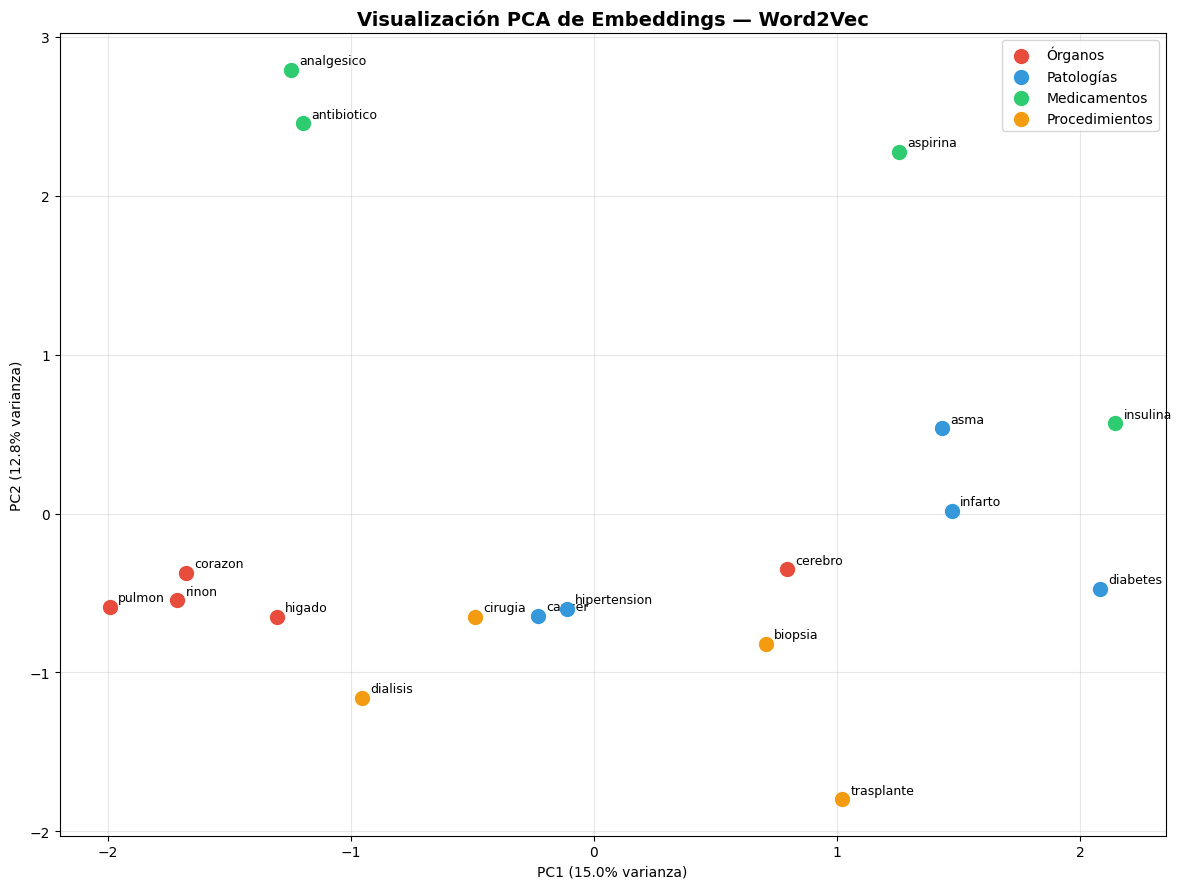

✅ Gráfica guardada en Drive


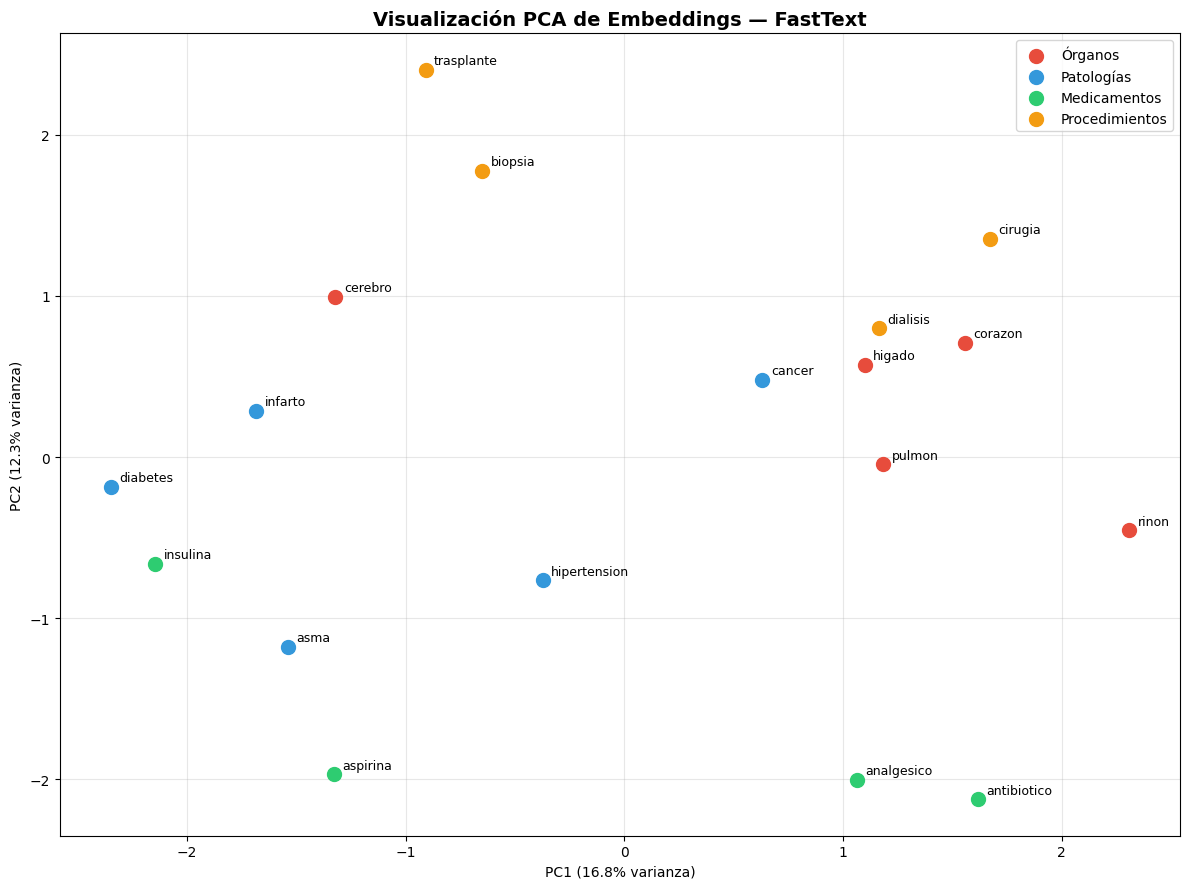

✅ Gráfica guardada en Drive


In [32]:
def visualizar_embeddings(modelo, nombre_modelo: str, grupos_viz: dict):
    """
    Proyecta vectores en 2D con PCA y los grafica por categoría.
    grupos_viz: dict con {categoria: [palabras]}
    """
    colores = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']
    fig, ax = plt.subplots(figsize=(12, 9))

    todas_palabras = []
    todos_vectores = []
    todas_categorias = []

    for categoria, palabras in grupos_viz.items():
        for p in palabras:
            if en_vocab(modelo, p):
                todas_palabras.append(p)
                todos_vectores.append(modelo.wv[p])
                todas_categorias.append(categoria)

    if len(todos_vectores) < 3:
        print('⚠️  Insuficientes palabras en vocabulario para visualizar')
        return

    # PCA a 2 dimensiones
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(np.array(todos_vectores))

    # Graficar por categoría
    categorias_unicas = list(dict.fromkeys(todas_categorias))
    for i, cat in enumerate(categorias_unicas):
        idxs = [j for j, c in enumerate(todas_categorias) if c == cat]
        xs = [coords[j, 0] for j in idxs]
        ys = [coords[j, 1] for j in idxs]
        ax.scatter(xs, ys, label=cat, color=colores[i % len(colores)], s=100, zorder=5)
        for j in idxs:
            ax.annotate(todas_palabras[j], (coords[j, 0], coords[j, 1]),
                       textcoords='offset points', xytext=(6, 4), fontsize=9)

    ax.set_title(f'Visualización PCA de Embeddings — {nombre_modelo}', fontsize=14, fontweight='bold')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR + f'pca_{nombre_modelo.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Gráfica guardada en Drive')


GRUPOS_VIZ = {
    'Órganos':        ['corazon', 'pulmon', 'higado', 'rinon', 'cerebro'],
    'Patologías':     ['infarto', 'diabetes', 'hipertension', 'cancer', 'asma'],
    'Medicamentos':   ['antibiotico', 'analgesico', 'insulina', 'aspirina'],
    'Procedimientos': ['cirugia', 'biopsia', 'dialisis', 'trasplante'],
}

visualizar_embeddings(w2v_model, 'Word2Vec', GRUPOS_VIZ)
visualizar_embeddings(ft_model,  'FastText',  GRUPOS_VIZ)

## ✅ Celda 15 — Verificación de archivos de entrega

In [ ]:
print('📦 ARCHIVOS GENERADOS PARA ENTREGA:\n')
archivos_entrega = [
    'word2vec_cowese.txt',
    'fasttext_cowese.txt',
    'word2vec_cowese.model',
    'fasttext_cowese.model',
    'pca_word2vec.png',
    'pca_fasttext.png',
]
for fname in archivos_entrega:
    ruta = OUTPUT_DIR + fname
    if os.path.exists(ruta):
        size = os.path.getsize(ruta) / (1024**2)
        print(f'  ✅ {fname:40s}  {size:8.1f} MB')
    else:
        print(f'  ❌ {fname:40s}  NO ENCONTRADO')

print()
print('📝 INSTRUCCIONES DE ENTREGA:')
print('  1. Descarga este notebook (.ipynb) desde Colab → Archivo → Descargar')
print('  2. Entrega el archivo word2vec_cowese.txt O fasttext_cowese.txt')
print('     (el .txt es el modelo en formato estándar Word2Vec)')
print('  3. El .model es para recargar el modelo en Python (opcional entregar)')